Calculated kLa for G = 30.0 m3/h: 47.3232 h^-1
Critical oxygen threshold (3 * Kcl): 0.90 mg/L

Minimum dissolved oxygen concentration reached: 4.5192 mg/L
✅ The system IS NOT oxygen limited.


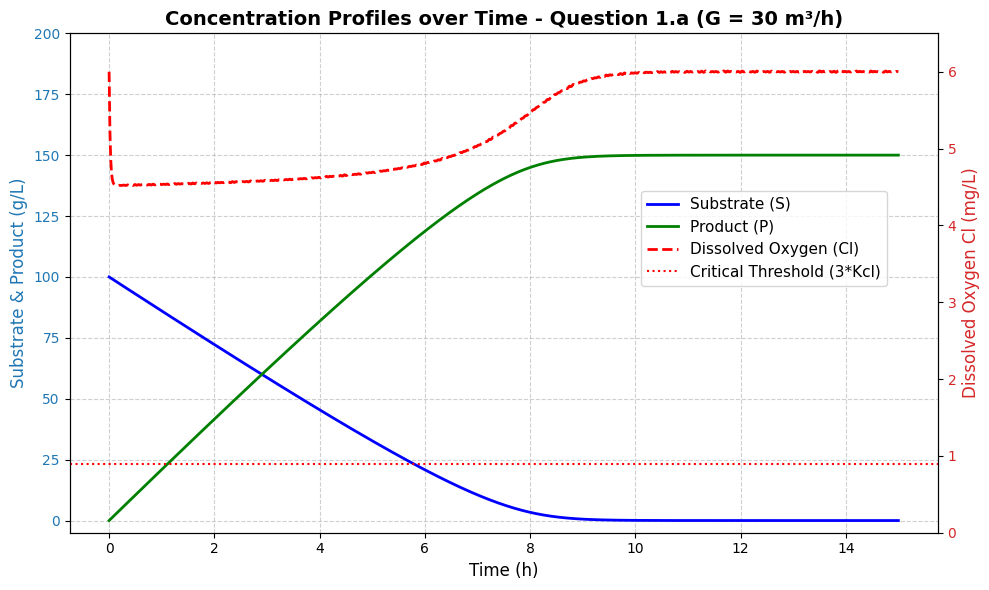

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# 1. SYSTEM PARAMETERS

# Kinetic and physical constants

k = 3.2e-13       # Oxygen transfer coefficient [m^3/(h^2)] (Note: unit as given in PDF) [cite: 40]
N = 30000.0       # Stirring rate / stirrer speed [h^-1] [cite: 34, 40]
G = 30.0          # Initial aeration rate [m^3/h] [cite: 34, 43]
Cl_star = 6.0     # Dissolved oxygen saturation concentration [mg/L] [cite: 40]

Vm = 16.0         # Maximum substrate consumption rate [g/(L*h)] [cite: 41]
Ks = 7.0          # Substrate saturation constant [g/L] [cite: 41]
Kcl = 0.3         # Dissolved oxygen saturation constant [mg/L] [cite: 41]

Y_O_S = 5.0       # Oxygen/substrate yield coefficient [mg/g] [cite: 42]
Y_P_S = 1.5       # Product/substrate yield coefficient [g/g] [cite: 42]

# KLa calculation parameters

kla = k * (N**3) * (G**0.5)  # Oxygen transfer coefficient [h^-1] (calculated from given parameters)
print(f"Calculated kLa for G = {G} m3/h: {kla:.4f} h^-1")

# Thresholds 
critical_threshold = 3 * Kcl # Substrate concentration threshold for growth [g/L]
print(f"Critical oxygen threshold (3 * Kcl): {critical_threshold:.2f} mg/L\n")

# 2 ODE SYSTEM DEFINITION

def reactor_system(t, y, Vm_current, kla_current):
    S, Cl, P = y

    # Range
    S=max(S, 0)  # Ensure substrate concentration doesn't go negative
    Cl=max(Cl, 0)  # Ensure dissolved oxygen concentration doesn't go negative

    # Kinetics ractions
    r_S = ((Vm_current * S) / (Ks + S)) * (Cl / (Kcl + Cl))  # Substrate consumption rate [g/(L*h)]

    # ODEs
    dS_dt = -r_S  # Substrate consumption
    dCl_dt = kla_current * (Cl_star - Cl) - Y_O_S * r_S  # Oxygen balance
    dP_dt = Y_P_S * r_S  # Product formation
    return [dS_dt, dCl_dt, dP_dt]

# 3. SIMULATION for a)

# Initial conditions
y0 = [100.0, 6.0, 0.0]  # [cite: 36, 37]
t_span = (0, 15)  # Time span long enough to fully reach steady state [cite: 21]

sol = solve_ivp(
    fun=lambda t, y: reactor_system(t, y, Vm, kla),
    t_span=t_span,
    y0=y0,
    method='RK45',  # Standard explicit Runge-Kutta method
    t_eval=np.linspace(t_span[0], t_span[1], 1000)
)
# Extraction

t_steps = sol.t
S_profile = sol.y[0]
Cl_profile = sol.y[1]
P_profile = sol.y[2]

# Oxygen limitation analysis

min_Cl = np.min(Cl_profile)
print(f"Minimum dissolved oxygen concentration reached: {min_Cl:.4f} mg/L")
if min_Cl <= critical_threshold:
    print("⚠️ The system IS oxygen limited!")  # [cite: 20]
else:
    print("✅ The system IS NOT oxygen limited.")  # [cite: 20]

# 4. PLOTTING RESULTS

fig, ax1 = plt.subplots(figsize=(10, 6))

# Primary Y-axis for Substrate (S) and Product (P) profiles [g/L]
color = 'tab:blue'
ax1.set_xlabel('Time (h)', fontsize=12)
ax1.set_ylabel('Substrate & Product (g/L)', color=color, fontsize=12)
line1 = ax1.plot(t_steps, S_profile, label='Substrate (S)', color='blue', linewidth=2)
line2 = ax1.plot(t_steps, P_profile, label='Product (P)', color='green', linewidth=2)
ax1.tick_params(axis='y', labelcolor=color)
ax1.grid(True, linestyle='--', alpha=0.6)

# CRITICAL FIX: Expand the left Y-axis limit so the green curve plateaus lower down
ax1.set_ylim(-5, 200)  # Max product is 150, so this leaves a 50 g/L gap at the top

# Secondary Y-axis for Dissolved Oxygen (Cl) profile [mg/L]
ax2 = ax1.twinx()  
color = 'tab:red'
ax2.set_ylabel('Dissolved Oxygen Cl (mg/L)', color=color, fontsize=12)
line3 = ax2.plot(t_steps, Cl_profile, label='Dissolved Oxygen (Cl)', color='red', linestyle='--', linewidth=2)
line4 = ax2.axhline(y=critical_threshold, color='red', linestyle=':', label='Critical Threshold (3*Kcl)')
ax2.tick_params(axis='y', labelcolor=color)

# CRITICAL FIX: Expand the right Y-axis limit downwards so the red curve stays higher up
ax2.set_ylim(0, 6.5)  # Keeps the oxygen curves visually separated from the product plateau

# Combine legends from both axes into a single box (moved to 'upper right' or 'center right')
lines = line1 + line2 + line3 + [line4]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper right', fontsize=11, bbox_to_anchor=(0.95, 0.70))

plt.title("Concentration Profiles over Time - Question 1.a (G = 30 m³/h)", fontsize=14, fontweight='bold')
fig.tight_layout()
plt.show()

Critical Aeration Rate (G_critical): 1.5819 m3/h
Minimum Cl at G_critical: 0.8822 mg/L


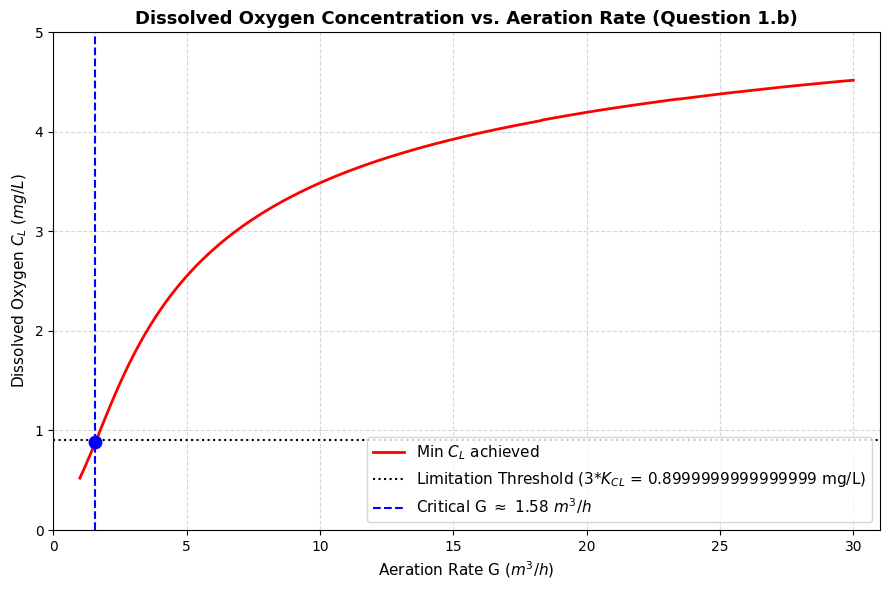

In [20]:
# 5. SIMULATION for b) - Increased aeration rate (G = 60 m³/h)
G_b = np.linspace(1, 30, 300)  # Increased aeration rate [m^3/h]
min_Cl_values = []  # To store minimum Cl for each G

for G_test in G_b:
    kla_test = k * (N**3) * (G_test**0.5)  # Recalculate kLa for each G
    sol_test = solve_ivp(
        fun=lambda t, y: reactor_system(t, y, Vm, kla_test),
        t_span=t_span,
        y0=y0,
        method='RK45',
        t_eval=np.linspace(t_span[0], t_span[1], 1000)
    )
    Cl_profile_test = sol_test.y[1]
    min_Cl_test = np.min(Cl_profile_test)
    min_Cl_values.append(min_Cl_test)

min_Cl_values = np.array(min_Cl_values)

# Treshold 
idx_critical = np.where(min_Cl_values <= critical_threshold)[0]
G_critical = np.max(G_b[idx_critical])
min_Cl_critical = min_Cl_values[idx_critical][-1]
print(f"Critical Aeration Rate (G_critical): {G_critical:.4f} m3/h")
print(f"Minimum Cl at G_critical: {min_Cl_critical:.4f} mg/L")

# 6 Plotting

plt.figure(figsize=(9, 6))
plt.plot(G_b, min_Cl_values, color='red', linewidth=2, label='Min $C_L$ achieved')
plt.axhline(y=critical_threshold, color='black', linestyle=':', linewidth=1.5, 
            label=f'Limitation Threshold (3*$K_{{CL}}$ = {critical_threshold} mg/L)')
plt.axvline(x=G_critical, color='blue', linestyle='--', linewidth=1.5, 
            label=f'Critical G $\\approx$ {G_critical:.2f} $m^3/h$')

# Highlight the intersection point
plt.scatter(G_critical, min_Cl_critical, color='blue', s=80, zorder=5)

plt.title("Dissolved Oxygen Concentration vs. Aeration Rate (Question 1.b)", fontsize=13, fontweight='bold')
plt.xlabel("Aeration Rate G ($m^3/h$)", fontsize=11)
plt.ylabel("Dissolved Oxygen $C_L$ ($mg/L$)", fontsize=11)
plt.xlim(0, 31)
plt.ylim(0, 5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()


Calculated kLa for G_critical = 1.5819 m3/h: 10.8670 h^-1


Results for Vm = 16.0 g/(L*h):
  - Time to reach steady state: 12.37 h
  - Average product formation rate: 12.1226 g/(L*h)
  - Minimum Cl reached: 0.8822 mg/L
  - Is it still oxygen limited? Yes

Results for Vm = 8.0 g/(L*h):
  - Time to reach steady state: 15.00 h
  - Average product formation rate: 9.1961 g/(L*h)
  - Minimum Cl reached: 2.8926 mg/L
  - Is it still oxygen limited? No


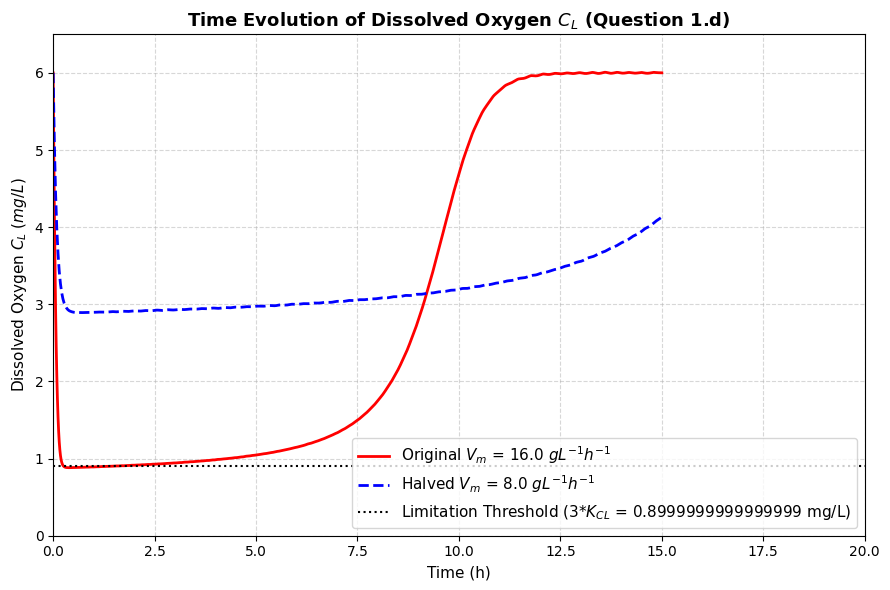

In [23]:
# 7 C)

# Vm

Vm_values = [16.0, 8.0]  # Range of Vm values [g/(L*h)]
Results = {}

# kla for G_critical
kla_critical = k * (N**3) * (G_critical**0.5)
print(f"Calculated kLa for G_critical = {G_critical:.4f} m3/h: {kla_critical:.4f} h^-1\n")

for Vm_test in Vm_values:
    sol_vm = solve_ivp(
        fun=lambda t, y: reactor_system(t, y, Vm_test, kla_critical),
        t_span=t_span,
        y0=y0,
        method='RK45',
        t_eval=np.linspace(t_span[0], t_span[1], 1000)
    )
    t_c = sol_vm.t
    S_c = sol_vm.y[0]
    Cl_c = sol_vm.y[1]
    P_c = sol_vm.y[2]

    # Find steady state values (last 10% of time points)
    idx_ss = np.where(S_c < 0.01)[0]  # Substrate effectively depleted
    if len(idx_ss) > 0:
        t_ss = t_c[idx_ss[0]]  # First index where substrate is depleted
        P_ss = P_c[idx_ss[0]]  # Corresponding product concentration at steady state
    else:
        t_ss = t_c[-1]
        P_ss = P_c[-1]

    # Average product formation rate
    avg_production_rate = (P_ss - P_c[0]) / t_ss

    min_Cl = np.min(Cl_c)

    # Results storage
    Results[Vm_test] = {
        't': t_c,
        'Cl': Cl_c,
        'P': P_c,
        't_ss': t_ss,
        'P_ss': P_ss,
        'avg_production_rate': avg_production_rate,
        'min_Cl': min_Cl
    }

    print(f"\nResults for Vm = {Vm_test} g/(L*h):")
    print(f"  - Time to reach steady state: {t_ss:.2f} h")
    print(f"  - Average product formation rate: {avg_production_rate:.4f} g/(L*h)")
    print(f"  - Minimum Cl reached: {min_Cl:.4f} mg/L")
    print(f"  - Is it still oxygen limited? {'Yes' if min_Cl <= critical_threshold + 1e-4 else 'No'}")

# 8 Plotting results for c)

plt.figure(figsize=(9, 6))

plt.plot(Results[16.0]['t'], Results[16.0]['Cl'], color='red', linewidth=2, 
         label='Original $V_m$ = 16.0 $g L^{-1} h^{-1}$')
plt.plot(Results[8.0]['t'], Results[8.0]['Cl'], color='blue', linewidth=2, linestyle='--',
         label='Halved $V_m$ = 8.0 $g L^{-1} h^{-1}$')

plt.axhline(y=critical_threshold, color='black', linestyle=':', linewidth=1.5, 
            label=f'Limitation Threshold (3*$K_{{CL}}$ = {critical_threshold} mg/L)')

plt.title("Time Evolution of Dissolved Oxygen $C_L$ (Question 1.d)", fontsize=13, fontweight='bold')
plt.xlabel("Time (h)", fontsize=11)
plt.ylabel("Dissolved Oxygen $C_L$ ($mg/L$)", fontsize=11)
plt.xlim(0, 20)
plt.ylim(0, 6.5)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

Original kLa (N = 30000.0 h^-1): 10.8670 h^-1
Calculated kLa for reduced agitation rate (N = 25500.0 h^-1): 6.6737 h^-1
Percentage drop in kLa due to 15% reduction in agitation rate: 38.59%

Minimum Cl reached with reduced N: 0.3106 mg/L
Maximum reaction rate r_s (Base): 14.2412 g/(L*h)
Maximum reaction rate r_s (Reduced N): 14.2412 g/(L*h)


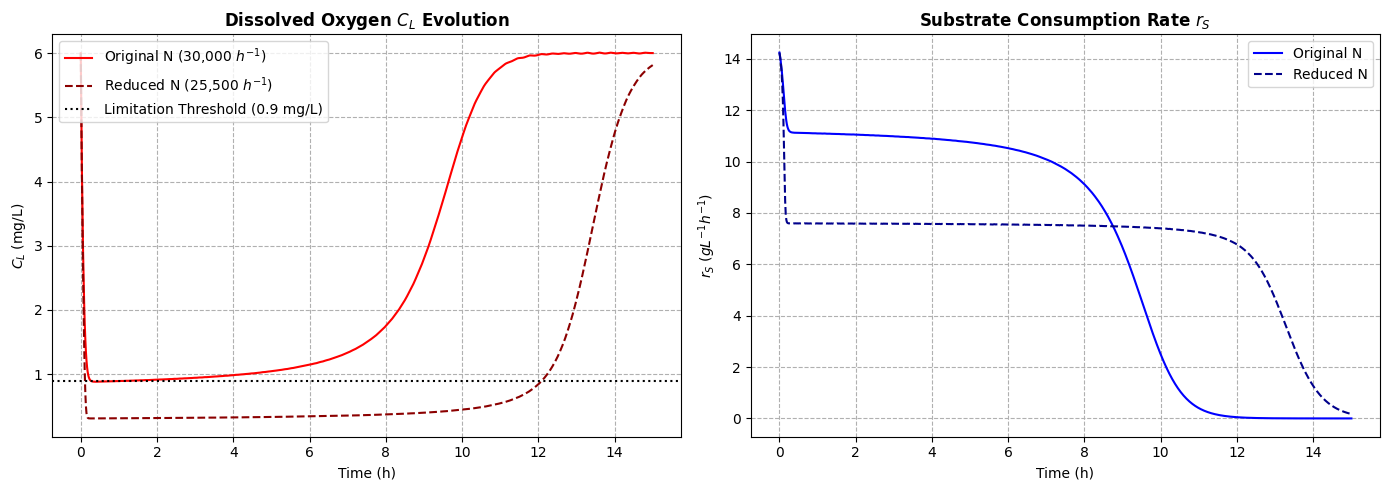

In [31]:
# 9 e)

# Parameters

N_original = 30000.0  # Original agitation rate [h^-1]
N_reduced= 0.85 * N_original  # Reduced agitation rate [h^-1]

# Recalculate kLa for reduced agitation rate
kla_original = k * (N_original**3) * (G_critical**0.5)
print(f"Original kLa (N = {N_original} h^-1): {kla_original:.4f} h^-1")
kla_reduced = k * (N_reduced**3) * (G_critical**0.5)
print(f"Calculated kLa for reduced agitation rate (N = {N_reduced} h^-1): {kla_reduced:.4f} h^-1")

# kla drop in percent 
kla_drop_percent = ((kla_original - kla_reduced) / kla_original) * 100
print(f"Percentage drop in kLa due to 15% reduction in agitation rate: {kla_drop_percent:.2f}%")

# 10 Simulation with reduced agitation rate

sol_reduced = solve_ivp(
    fun=lambda t, y: reactor_system(t, y, Vm, kla_reduced),
    t_span=t_span,
    y0=y0,
    method='RK45',
    t_eval=np.linspace(t_span[0], t_span[1], 1000)
)

# Extraction

t_reduced = sol_reduced.t
S_reduced = sol_reduced.y[0]
Cl_reduced = sol_reduced.y[1]
P_reduced = sol_reduced.y[2]

# r_s for reduced agitation

def get_rs_profile(S_profile, Cl_profile, Vm_val):
    r_s_profile = ((Vm_val * S_profile) / (Ks + S_profile)) * (Cl_profile / (Kcl + Cl_profile))
    return r_s_profile

# Re simulate base critical case for comparison
sol_base_critical = solve_ivp(
    fun=lambda t, y: reactor_system(t, y, Vm, kla_critical),
    t_span=t_span,
    y0=y0,
    method='RK45',
    t_eval=np.linspace(t_span[0], t_span[1], 1000)
)

rs_base = get_rs_profile(sol_base_critical.y[0], sol_base_critical.y[1], Vm)
rs_reduced = get_rs_profile(S_reduced, Cl_reduced, Vm)

print(f"\nMinimum Cl reached with reduced N: {np.min(Cl_reduced):.4f} mg/L")
print(f"Maximum reaction rate r_s (Base): {np.max(rs_base):.4f} g/(L*h)")
print(f"Maximum reaction rate r_s (Reduced N): {np.max(rs_reduced):.4f} g/(L*h)")

# Plotting r_s profiles for base critical case and reduced agitation case
fig, (ax_cl, ax_rs) = plt.subplots(1, 2, figsize=(14, 5))

# Plot for Cl
ax_cl.plot(sol_base_critical.t, sol_base_critical.y[1], color='red', label='Original N (30,000 $h^{-1}$)')
ax_cl.plot(t_reduced, Cl_reduced, color='darkred', linestyle='--', label='Reduced N (25,500 $h^{-1}$)')
ax_cl.axhline(y=critical_threshold, color='black', linestyle=':', label='Limitation Threshold (0.9 mg/L)')
ax_cl.set_title('Dissolved Oxygen $C_L$ Evolution', fontweight='bold')
ax_cl.set_xlabel('Time (h)')
ax_cl.set_ylabel('$C_L$ (mg/L)')
ax_cl.grid(True, linestyle='--')
ax_cl.legend()

# Plot for rs
ax_rs.plot(sol_base_critical.t, rs_base, color='blue', label='Original N')
ax_rs.plot(t_reduced, rs_reduced, color='darkblue', linestyle='--', label='Reduced N')
ax_rs.set_title('Substrate Consumption Rate $r_S$', fontweight='bold')
ax_rs.set_xlabel('Time (h)')
ax_rs.set_ylabel('$r_S$ ($g L^{-1} h^{-1}$)')
ax_rs.grid(True, linestyle='--')
ax_rs.legend()

plt.tight_layout()
plt.show()



--- VALIDATING COMBINATIONS FOR QUESTION 1.f ---
Case 1: Low N (20k), Very High G (55) -> Min Cl: 2.4961 mg/L | Safe? True
Case 2: Moderate N (25k), Moderate G (35) -> Min Cl: 3.6687 mg/L | Safe? True
Case 3: Base Case (30k), Base G (30) -> Min Cl: 4.5192 mg/L | Safe? True
Case 4: High N (35k), Low G (15) -> Min Cl: 4.6772 mg/L | Safe? True
Case 5: Very High N (40k), Minimal G (5) -> Min Cl: 4.4709 mg/L | Safe? True


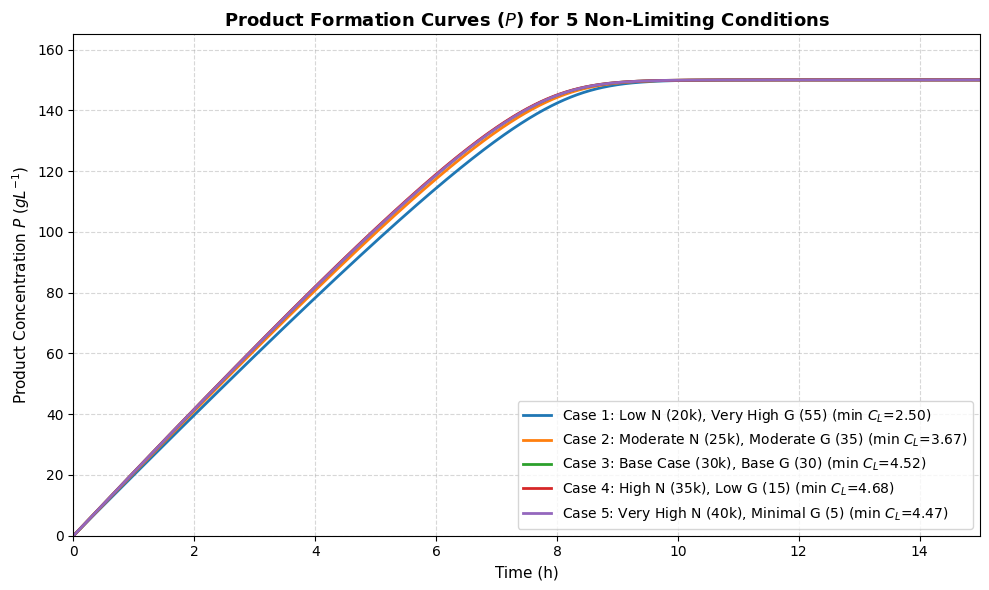

In [41]:
# 11 f)

# Define 5 combinations od N and G above the critical threshold

combinations = [
    (20000.0, 55.0, "Case 1: Low N (20k), Very High G (55)"),
    (25000.0, 35.0, "Case 2: Moderate N (25k), Moderate G (35)"),
    (30000.0, 30.0, "Case 3: Base Case (30k), Base G (30)"),
    (35000.0, 15.0, "Case 4: High N (35k), Low G (15)"),
    (40000.0, 5.0,  "Case 5: Very High N (40k), Minimal G (5)")
]
plt.figure(figsize=(10, 6))

print("--- VALIDATING COMBINATIONS FOR QUESTION 1.f ---")

for N_combo, G_combo, label in combinations:
    # 1. Calculate specific kLa for this combination
    kla_combo = k * (N_combo**3) * np.sqrt(G_combo)
    
    # 2. Run simulation
    sol_combo = solve_ivp(
        fun=lambda t, y: reactor_system(t, y, Vm, kla_combo),
        t_span=(0, 15),
        y0=y0,
        method='RK45',
        t_eval=np.linspace(0, 15, 1000)
    )
    
    # 3. Double-check to ensure it is truly non-limiting
    min_Cl_combo = np.min(sol_combo.y[1])
    is_safe = min_Cl_combo > critical_threshold
    print(f"{label} -> Min Cl: {min_Cl_combo:.4f} mg/L | Safe? {is_safe}")
    
    # 4. Plot the Product (P) formation curve
    plt.plot(sol_combo.t, sol_combo.y[2], linewidth=2, label=f"{label} (min $C_L$={min_Cl_combo:.2f})")

# Formatting the plot
plt.title("Product Formation Curves ($P$) for 5 Non-Limiting Conditions", fontsize=13, fontweight='bold')
plt.xlabel("Time (h)", fontsize=11)
plt.ylabel("Product Concentration $P$ ($g L^{-1}$)", fontsize=11)
plt.xlim(0, 15)
plt.ylim(0, 165)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()